# Predicting the Results of Professional Tennis Matches with Machine Learning 

## 1. Setup

### Required libraries

In [ ]:
%pip install -q pandas matplotlib numpy scikit-learn xgboost catboost shap

### Library imports

In [41]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from catboost import CatBoostClassifier
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

### Configuration

In [138]:
# Dataset file
DATA_DIR = Path.cwd().parent / "data"
DATA_FILE = DATA_DIR / "atp_matches.csv"

# Random state for reproducibility
RANDOM_STATE = 42

# Target feature
TARGET_FEATURE = "winner"

# Present on the dataframe but ignored by classifiers
METADATA_FEATURES = {
    "tournament_id",
    "tournament_start_date",
    "tournament_name",
    "match_num",
    "player1_id",
    "player2_id",
    "player1_name",
    "player2_name",
    "score",
}

# Force certain numeric features to be treated as categorical
AS_CATEGORICAL = {
    "best_of",
}

# Features that, if missing, means rows will be dropped
DROP_MISSING_FEATURES = {
    "player1_rank",
    "player2_rank",
    "player1_points",
    "player2_points",
}

# Features to completely drop from the dataset (useful for testing)
DROP_FEATURES = {
    # "player1_points",
    # "player2_points",
}

# Testing and trainingparameters
TRAIN_RATIO = 0.8
TEST_RATIO = 1 - TRAIN_RATIO
NUM_CV_SPLITS = 10

### Helpers

In [79]:
TOURNAMENT_LEVEL_LABELS = {
    "A": "ATP 250 and 500",
    "D": "Davis Cup",
    "F": "ATP Finals",
    "G": "Grand Slam",
    "M": "Masters 1000",
    "N": "Next Gen Finals",
    "O": "Olympics",
}

## 2. Data Loading

In [150]:
if DATA_FILE.is_file():
    raw_df = pd.read_csv(DATA_FILE)
else:
    raise FileNotFoundError(
        "Failed to find or read dataset file."
    )

(num_rows, num_cols) = raw_df.shape
print(f"Dataset has {num_rows:,} rows and {num_cols} columns.")

Dataset has 189,373 rows and 63 columns.


## 3. Data Exploration

### Distribution of matches where the winner is player1

In [151]:
# winner == 1 means player1 won; winner == 2 means player2 won
player1_wins = (raw_df[TARGET_FEATURE] == 1).sum()
n_matches = len(raw_df)
pct_player1 = 100 * player1_wins / n_matches

print(
    f"Player1 win rate: {pct_player1:.2f}% "
    f"({player1_wins:,} of {n_matches:,} matches)"
)

Player1 win rate: 50.13% (94,942 of 189,373 matches)


### Matches per year by tournament level

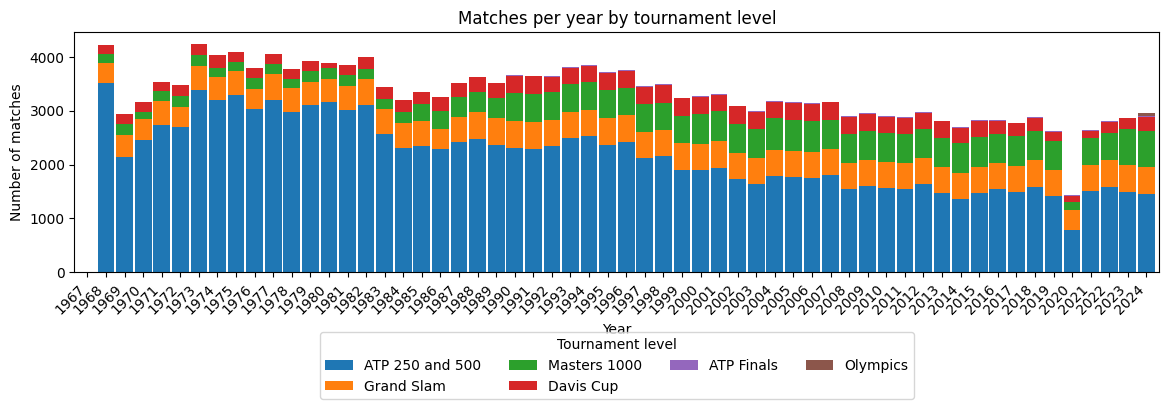

In [153]:
counts_by_year_level = (
    raw_df.groupby(["year", "tournament_level"], observed=True)
    .size()
    .unstack(fill_value=0)
)

# Stack order: most common levels at the bottom of the stack
level_order = counts_by_year_level.sum().sort_values(ascending=False).index
counts_by_year_level = counts_by_year_level.reindex(columns=level_order, fill_value=0)
counts_by_year_level = counts_by_year_level.rename(
    columns=lambda c: TOURNAMENT_LEVEL_LABELS.get(str(c), str(c))
)

fig, ax = plt.subplots(figsize=(14, 4))
counts_by_year_level.plot(ax=ax, kind="bar", stacked=True, width=0.9)
ax.set_xlabel("Year")
ax.set_ylabel("Number of matches")
ax.set_title("Matches per year by tournament level")
n_levels = counts_by_year_level.shape[1]
ax.legend(
    title="Tournament level",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=min(n_levels, 4),
)
plt.xticks(rotation=45, ha="right")
fig.subplots_adjust(bottom=0.28)
plt.show()

### Rank coverage by month

Share of matches where both players have a known ATP ranking (`player1_rank` and `player2_rank` is not empty).

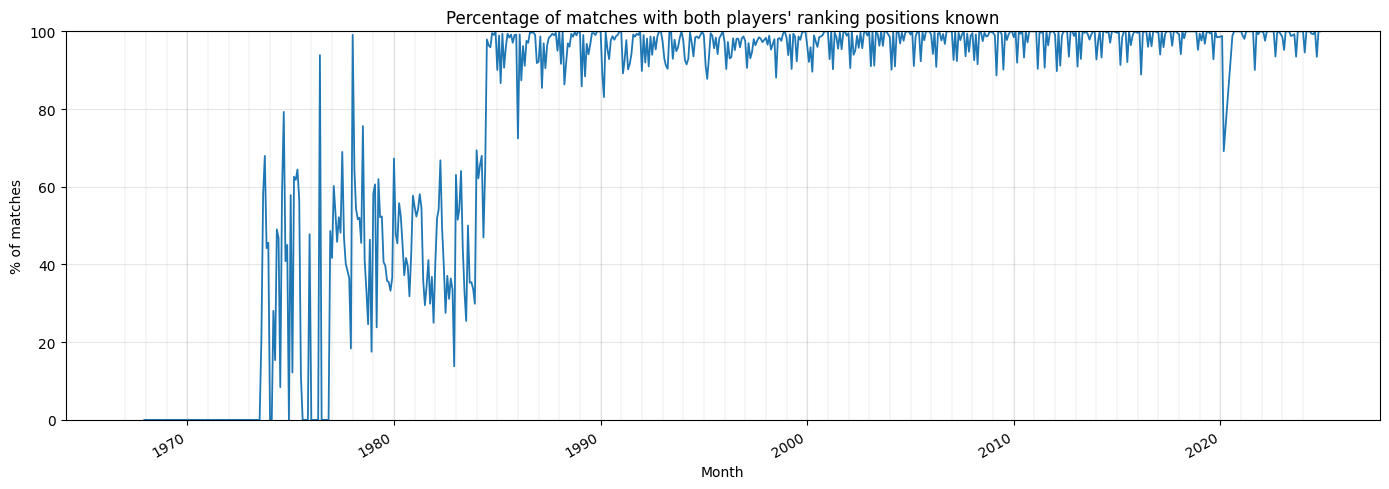

In [154]:
month_dt = pd.to_datetime(raw_df["tournament_start_date"], errors="coerce")
rank_df = raw_df.assign(month=month_dt.dt.to_period("M")).dropna(subset=["month"])
both_ranks_known = rank_df["player1_rank"].notna() & rank_df["player2_rank"].notna()
pct_both_ranks_by_month = (
    rank_df.assign(both_ranks_known=both_ranks_known)
    .groupby("month", observed=True)["both_ranks_known"]
    .mean()
    * 100
)

fig, ax = plt.subplots(figsize=(14, 5))

year_min = pct_both_ranks_by_month.index.min().year
year_max = pct_both_ranks_by_month.index.max().year
for y in range(year_min, year_max + 1):
    ax.axvline(
        pd.Timestamp(year=y, month=1, day=1),
        color="#d8d8d8",
        linewidth=0.3,
        zorder=0,
    )

ax.plot(
    pct_both_ranks_by_month.index.to_timestamp(),
    pct_both_ranks_by_month.values,
    linewidth=1.3,
    zorder=2,
)
ax.set_xlabel("Month")
ax.set_ylabel("% of matches")
ax.set_title("Percentage of matches with both players' ranking positions known")
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Matches per year by tournament level after dropping rows with missing features

Stacked bars match the earlier “matches per year by tournament level” figure, after rows with missing features were dropped.

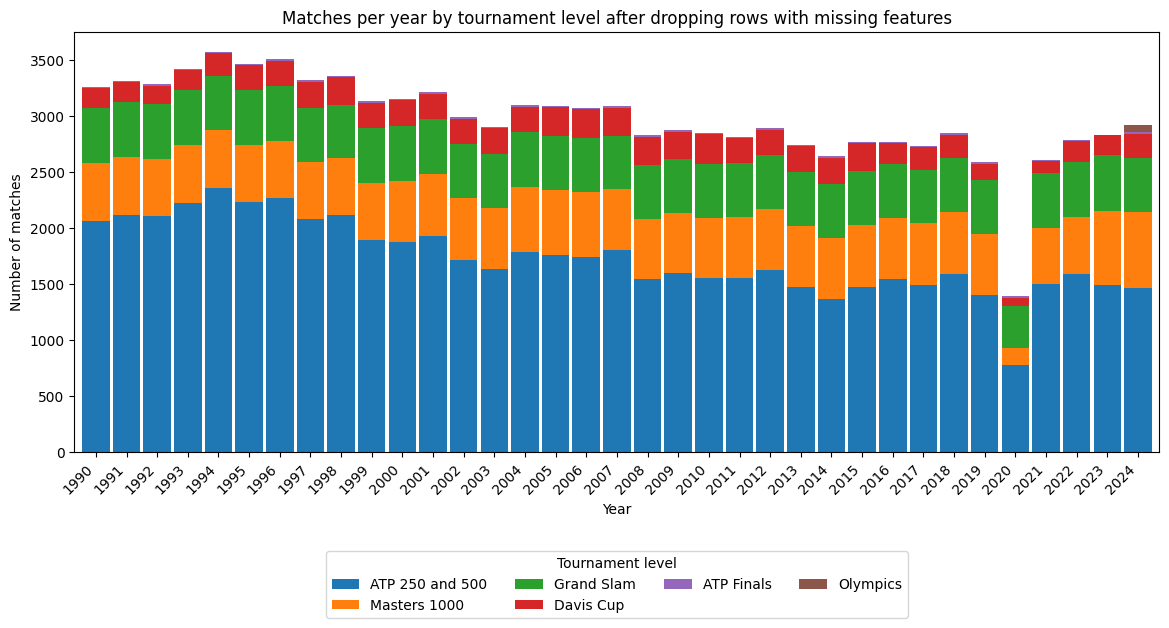

In [155]:
full_ranking_df = raw_df.dropna(
    subset=DROP_MISSING_FEATURES,
    how="any",
)

counts_by_year_level_full = (
    full_ranking_df.groupby(["year", "tournament_level"], observed=True)
    .size()
    .unstack(fill_value=0)
)

level_order = counts_by_year_level_full.sum().sort_values(ascending=False).index
counts_by_year_level_full = counts_by_year_level_full.reindex(
    columns=level_order, fill_value=0
)
counts_by_year_level_full = counts_by_year_level_full.rename(
    columns=lambda c: TOURNAMENT_LEVEL_LABELS.get(str(c), str(c))
)

fig, ax = plt.subplots(figsize=(14, 7))
counts_by_year_level_full.plot(ax=ax, kind="bar", stacked=True, width=0.9)
ax.set_xlabel("Year")
ax.set_ylabel("Number of matches")
ax.set_title(
    "Matches per year by tournament level after dropping rows with missing features"
)
n_levels = counts_by_year_level_full.shape[1]
ax.legend(
    title="Tournament level",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=min(n_levels, 4),
)
plt.xticks(rotation=45, ha="right")
fig.subplots_adjust(bottom=0.28)
plt.show()

### Favorite wins by month

Among matches where **both** `player1_rank` and `player2_rank` are known, the share of matches won by the **better-ranked** player (lower ATP rank number). Rows with **identical** ranks are excluded. Monthly percentage is over that filtered set only.

Overall: better-ranked player wins 66.24% of eligible matches (92,677 of 139,906).


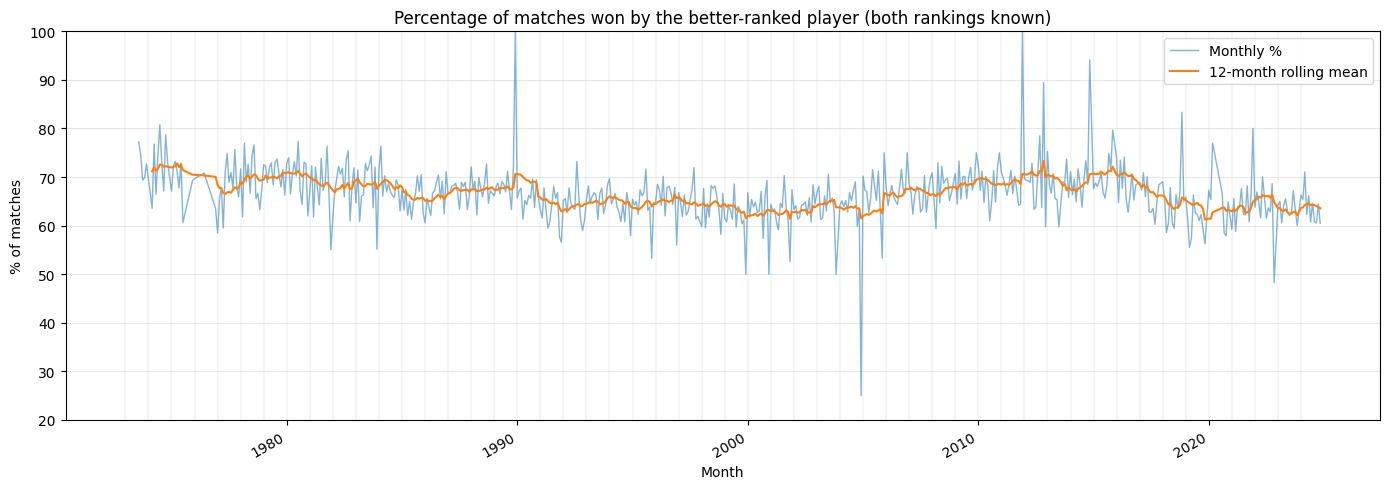

In [156]:
month_dt = pd.to_datetime(raw_df["tournament_start_date"], errors="coerce")
fav_df = raw_df.assign(month=month_dt.dt.to_period("M")).dropna(subset=["month"])

both_ranks_known = fav_df["player1_rank"].notna() & fav_df["player2_rank"].notna()
fav_df = fav_df.loc[both_ranks_known]

# Drop ties — no unique "better-ranked" player (same rank on both sides)
fav_df = fav_df[fav_df["player1_rank"] != fav_df["player2_rank"]]

favorite_wins = (
    ((fav_df["player1_rank"] < fav_df["player2_rank"]) & (fav_df[TARGET_FEATURE] == 1))
    | ((fav_df["player2_rank"] < fav_df["player1_rank"]) & (fav_df[TARGET_FEATURE] == 2))
)

n_eligible = len(fav_df)
pct_favorite_overall = 100 * favorite_wins.mean()
print(
    f"Overall: better-ranked player wins {pct_favorite_overall:.2f}% of eligible matches "
    f"({int(favorite_wins.sum()):,} of {n_eligible:,})."
)

pct_favorite_by_month = (
    fav_df.assign(favorite_wins=favorite_wins)
    .groupby("month", observed=True)["favorite_wins"]
    .mean()
    * 100
)

ROLL_MONTHS = 12
running_avg = pct_favorite_by_month.rolling(window=ROLL_MONTHS, min_periods=6).mean()

ts = pct_favorite_by_month.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))

year_min = pct_favorite_by_month.index.min().year
year_max = pct_favorite_by_month.index.max().year
for y in range(year_min, year_max + 1):
    ax.axvline(
        pd.Timestamp(year=y, month=1, day=1),
        color="#d8d8d8",
        linewidth=0.3,
        zorder=0,
    )

ax.plot(
    ts,
    pct_favorite_by_month.values,
    linewidth=1.0,
    alpha=0.55,
    label="Monthly %",
    zorder=2,
)
ax.plot(
    ts,
    running_avg.values,
    linewidth=1.5,
    label=f"{ROLL_MONTHS}-month rolling mean",
    zorder=3,
)
ax.set_xlabel("Month")
ax.set_ylabel("% of matches")
ax.set_title(
    "Percentage of matches won by the better-ranked player "
    "(both rankings known)"
)
ax.set_ylim(20, 100)
ax.set_yticks(np.arange(20, 101, 10))
ax.grid(True, alpha=0.3, axis="y", which="major")
ax.legend(loc="best")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Favorite agreement with outcome by year

For each calendar year, the chart shows the **percentage of matches** in which the **pre-match favorite** (by ATP ranking or by each overall rating) **won**. **Ranking:** lower rank number is better (when `player1_rank` is strictly lower than `player2_rank`, player 1 is the favorite). **Ratings:** higher value is better (same convention). Rows with **missing** values or a **tie** on the relevant pair of columns are excluded from that metric’s yearly percentage. Surface-specific ratings are not shown.

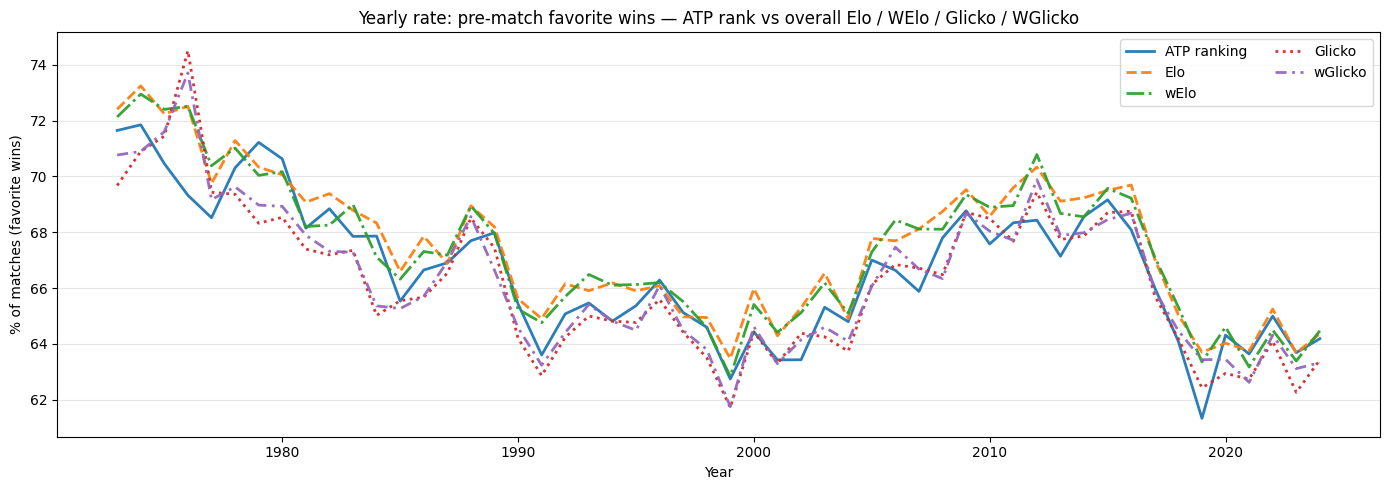

In [157]:
year_series = pd.to_datetime(raw_df["tournament_start_date"], errors="coerce").dt.year
plot_df = raw_df.assign(year=year_series).dropna(subset=["year"])
plot_df["year"] = plot_df["year"].astype(int)


def yearly_favorite_agreement_pct(df, col1, col2, *, lower_is_better: bool) -> pd.Series:
    """Per-year % of matches where the favorite (by col1 vs col2 ordering) won."""
    sub = df.dropna(subset=[col1, col2, TARGET_FEATURE, "year", "player1_rank", "player2_rank"]).copy()
    sub = sub[sub[col1] != sub[col2]]
    if lower_is_better:
        agree = (
            ((sub[col1] < sub[col2]) & (sub[TARGET_FEATURE] == 1))
            | ((sub[col2] < sub[col1]) & (sub[TARGET_FEATURE] == 2))
        )
    else:
        agree = (
            ((sub[col1] > sub[col2]) & (sub[TARGET_FEATURE] == 1))
            | ((sub[col2] > sub[col1]) & (sub[TARGET_FEATURE] == 2))
        )
    return sub.assign(_agree=agree).groupby("year", observed=True)["_agree"].mean() * 100


METRICS = [
    ("player1_rank", "player2_rank", True, "ATP ranking", "#1f77b4", "-"),
    ("player1_elo", "player2_elo", False, "Elo", "#ff7f0e", "--"),
    ("player1_welo", "player2_welo", False, "wElo", "#2ca02c", "-."),
    ("player1_glicko", "player2_glicko", False, "Glicko", "#d62728", ":"),
    ("player1_wglicko", "player2_wglicko", False, "wGlicko", "#9467bd", (0, (4, 2, 1, 2))),
]

fig, ax = plt.subplots(figsize=(14, 5))

for col1, col2, lower_flag, label, color, linestyle in METRICS:
    if col1 not in plot_df.columns or col2 not in plot_df.columns:
        raise KeyError(f"Missing columns for {label}: {col1}, {col2}")
    series = yearly_favorite_agreement_pct(plot_df, col1, col2, lower_is_better=lower_flag)
    ax.plot(
        series.index,
        series.values,
        linewidth=2.0,
        label=label,
        color=color,
        linestyle=linestyle,
        alpha=0.95,
    )

ax.set_xlabel("Year")
ax.set_ylabel("% of matches (favorite wins)")
ax.set_title(
    "Yearly rate: pre-match favorite wins — ATP rank vs overall Elo / WElo / Glicko / WGlicko"
)
ax.grid(True, alpha=0.3, axis="y")
ax.legend(loc="best", ncol=2)
plt.tight_layout()
plt.show()

### Unknown rankings by tournament level after 1985

Among matches where **at least one** of `player1_rank` or `player2_rank` is missing, how those rows split across tournament levels (pie chart). Only matches from **1985** onward are included.

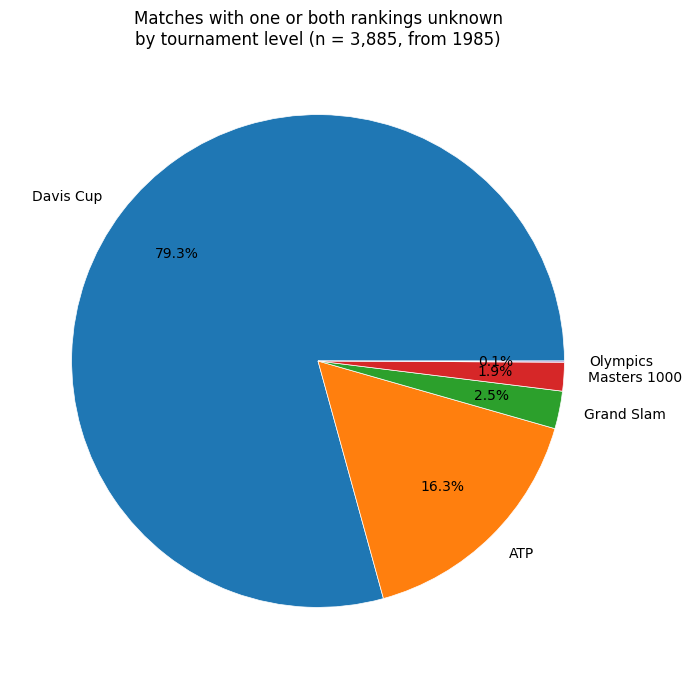

In [175]:
matches_from_1985 = raw_df[raw_df["year"] >= 1985]
one_or_both_unknown = (
    matches_from_1985["player1_rank"].isna()
    | matches_from_1985["player2_rank"].isna()
)
unknown_rank_df = matches_from_1985.loc[one_or_both_unknown]

counts_by_level = unknown_rank_df["tournament_level"].value_counts().sort_values(
    ascending=False
)
labels = [TOURNAMENT_LEVEL_LABELS.get(str(level), str(level)) for level in counts_by_level.index]

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(
    counts_by_level.values,
    labels=labels,
    autopct="%1.1f%%",
    pctdistance=0.72,
    wedgeprops=dict(linewidth=0.5, edgecolor="white"),
)
ax.set_title(
    "Matches with one or both rankings unknown\nby tournament level "
    f"(n = {len(unknown_rank_df):,}, from 1985)"
)
plt.show()

## 4. Data Preparation

### Remove rows with missing features, as specified by `DROP_MISSING_FEATURES`.

In [158]:
n_loaded = len(raw_df)
raw_df = raw_df.dropna(
    subset=DROP_MISSING_FEATURES,
    how="any",
)
n_after_drop = len(raw_df)

(num_rows, num_cols) = raw_df.shape
print(f"Dataset has {num_rows:,} rows and {num_cols} columns.")
print(
    f"Dropped {n_loaded - n_after_drop:,} rows with missing features"
)

Dataset has 104,092 rows and 63 columns.
Dropped 85,281 rows with missing features


### Feature selection

Metadata features are not used as input (leakage) but remain on the feature matrix.

In [159]:
feature_cols = [c for c in raw_df.columns if c != TARGET_FEATURE and c not in DROP_FEATURES]
X = raw_df[feature_cols].copy()
y = (raw_df[TARGET_FEATURE] == 1).astype(int)

metadata_cols = [c for c in METADATA_FEATURES if c in X.columns]

numeric_features = [
    c
    for c in X.select_dtypes(include=[np.number]).columns
    if c not in METADATA_FEATURES and c not in AS_CATEGORICAL
]
categorical_features = list(AS_CATEGORICAL) + [
    c
    for c in X.select_dtypes(exclude=[np.number]).columns
    if c not in METADATA_FEATURES
]

print(f"Target feature: {TARGET_FEATURE}")
print(f"{len(X.columns)} total features, of which:")
print(f"- {len(metadata_cols)} metadata features: {metadata_cols}")
print(f"- {len(categorical_features)} categorical features: {categorical_features}")
print(f"- {len(numeric_features)} numeric features")

Target feature: winner
62 total features, of which:
- 9 metadata features: ['tournament_id', 'player2_id', 'tournament_start_date', 'player1_id', 'player1_name', 'score', 'tournament_name', 'player2_name', 'match_num']
- 5 categorical features: ['best_of', 'tournament_level', 'surface', 'player1_hand', 'player2_hand']
- 48 numeric features


### Dataset split for training and testing

After the random split, the **training** rows are ordered by parsed **`tournament_start_date`**, then **`tournament_id`**, so time-based cross-validation (`TimeSeriesSplit`) runs in chronological order.

In [160]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_RATIO, random_state=RANDOM_STATE
)

X_train = X_train.assign(
    _sort_date=pd.to_datetime(X_train["tournament_start_date"], errors="coerce")
)
_train_order = X_train.sort_values(
    by=["_sort_date", "tournament_id"],
    kind="stable",
    na_position="last",
).index
X_train = (
    X_train.loc[_train_order]
    .drop(columns="_sort_date")
    .reset_index(drop=True)
)
y_train = y_train.loc[_train_order].reset_index(drop=True)

n = len(X)
print(
    f"Train pool: {len(X_train):,} ({len(X_train) / n:.0%}), "
    f"Hold-out test: {len(X_test):,} ({len(X_test) / n:.0%})"
)

Train pool: 83,273 (80%), Hold-out test: 20,819 (20%)


## 5. Common Training and Testing Infrastructure

### Training and testing approach

**`GridSearchCV`** searches best parameters using **`TimeSeriesSplit`** with **`NUM_CV_SPLITS`** splits (expanding training windows in row order, which is set to be in chronological order after train/test split), then refit on the full training pool; hold-out test uses **`TEST_RATIO`** of rows.


In [161]:
def train_model(model_name, estimator, param_grid):
    cv = TimeSeriesSplit(n_splits=NUM_CV_SPLITS)
    grid_search = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1,
        refit=True,
        verbose=1,
    )
    grid_search.fit(X_train, y_train)

    cv_res = grid_search.cv_results_
    n_candidates = len(cv_res["params"])
    fold_x = np.arange(1, NUM_CV_SPLITS + 1)

    fig, ax = plt.subplots(figsize=(14, 6))
    for i in range(n_candidates):
        ys = [cv_res[f"split{j}_test_score"][i] for j in range(NUM_CV_SPLITS)]
        ax.plot(
            fold_x,
            ys,
            marker="o",
            linewidth=1.2,
            alpha=0.85,
            label=f"Parameter set {i}",
        )

    print("\nParameter sets ranked by test score")
    for pos, rank in sorted(enumerate(cv_res["rank_test_score"]), key=lambda x: x[1]):
        params = cv_res["params"][pos]
        score = cv_res["mean_test_score"][pos]
        print(f"#{rank} - Parameter set {pos} with score {score}:\n  {params}")

    ax.set_xlabel("CV fold (test split)")
    ax.set_ylabel(f"Test score ({grid_search.scoring})")
    ax.set_title(
        f"{model_name}: GridSearchCV test score per fold — each line is one parameter set"
    )
    ax.set_xticks(fold_x)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    ncol = min(max(n_candidates, 1), 4)

    fig.tight_layout(rect=[0, 0.12 + 0.02 * int(np.ceil(n_candidates / ncol)), 1, 1])
    plt.show()

    print(f"\nGrid search for {model_name} model")
    print(f"\nBest CV score (mean across folds): {grid_search.best_score_:.4f}")
    print(f"Best params: {grid_search.best_params_}")

    return grid_search.best_estimator_, grid_search.cv_results_

def test_model(model_name, model):
    pred = model.predict(X_test)
    proba_p1 = model.predict_proba(X_test)[:, 1]
    n_correct = int((y_test == pred).sum())
    n_total = len(y_test)
    prec = precision_score(
        y_test, pred, average="binary", pos_label=1, zero_division=0
    )
    rec = recall_score(
        y_test, pred, average="binary", pos_label=1, zero_division=0
    )
    f1 = f1_score(y_test, pred, average="binary", pos_label=1, zero_division=0)
    auc = roc_auc_score(y_test, proba_p1)
    print(f"\nTest results for {model_name} model")
    print(
        f"{n_correct:,} / {n_total:,} correct ({n_correct / n_total:.2%}); "
        f"precision={prec:.4f}, recall={rec:.4f}, F1={f1:.4f}, ROC-AUC={auc:.4f}"
    )

def shap_analysis(pipeline):
    # Extract the fitted model from the pipeline
    model = pipeline.named_steps['model']
    prep = pipeline.named_steps['prep']

    # Extract the preprocessing steps to transform the data
    X_test_transformed = prep.transform(X_test)

    # Get the feature names
    feature_names = prep.get_feature_names_out()

    # Convert back to a DataFrame so SHAP has column names
    X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

    # Initialize TreeExplainer with the extracted model
    explainer = shap.TreeExplainer(model, X_test_df)
    explanation = explainer(X_test_df)

    # Plots
    shap.plots.bar(explanation, max_display=60)
    shap.plots.beeswarm(explanation, max_display=30)

def train_and_test_model(model_name, estimator, param_grid):
    model, _ = train_model(model_name, estimator, param_grid)
    test_model(model_name, model)
    return model


## 5. Models

### Random Forest

Fitting 10 folds for each of 4 candidates, totalling 40 fits


/Users/sergio.carvalho/.pyenv/versions/3.13.2/envs/jupyter/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Parameter sets ranked by test score
#1 - Parameter set 3 with score 0.6770805812417439:
  {'model__class_weight': 'balanced', 'model__max_depth': 20, 'model__min_samples_leaf': 4, 'model__n_estimators': 200, 'model__random_state': 42}
#2 - Parameter set 1 with score 0.6758784676354029:
  {'model__class_weight': 'balanced', 'model__max_depth': None, 'model__min_samples_leaf': 4, 'model__n_estimators': 200, 'model__random_state': 42}
#3 - Parameter set 2 with score 0.6751783355350067:
  {'model__class_weight': 'balanced', 'model__max_depth': 20, 'model__min_samples_leaf': 2, 'model__n_estimators': 200, 'model__random_state': 42}
#4 - Parameter set 0 with score 0.6746367239101717:
  {'model__class_weight': 'balanced', 'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__n_estimators': 200, 'model__random_state': 42}


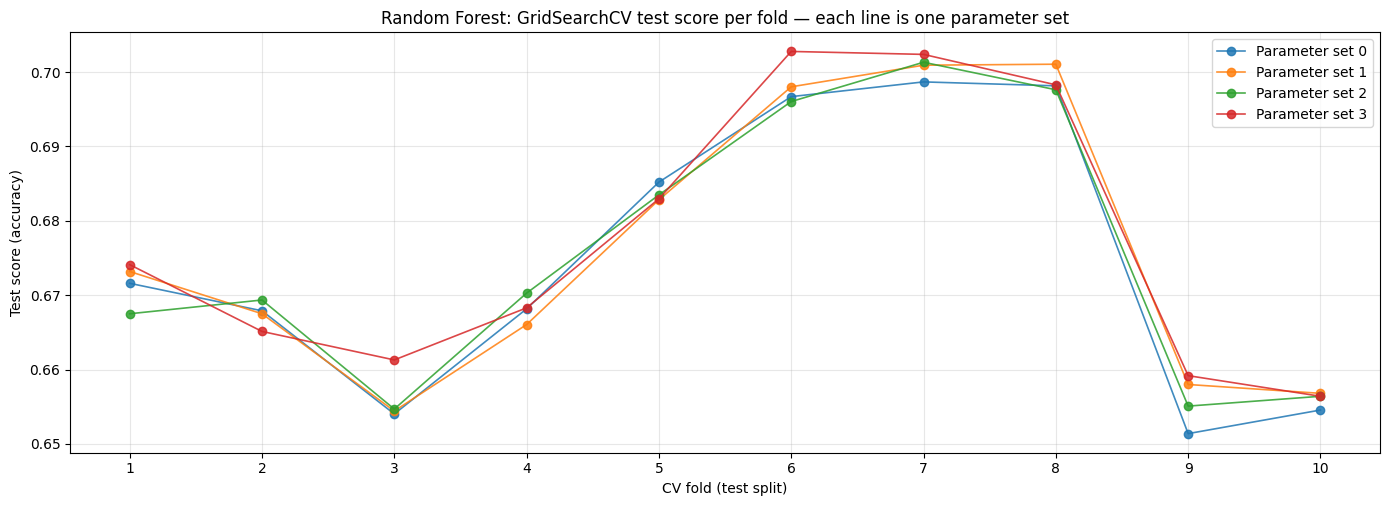


Grid search for Random Forest model

Best CV score (mean across folds): 0.6771
Best params: {'model__class_weight': 'balanced', 'model__max_depth': 20, 'model__min_samples_leaf': 4, 'model__n_estimators': 200, 'model__random_state': 42}

Test results for Random Forest model
14,020 / 20,819 correct (67.34%); precision=0.6762, recall=0.6724, F1=0.6743, ROC-AUC=0.7377


In [55]:
RF_MODEL_NAME = "Random Forest"

# RandomForest hyperparameters for GridSearchCV (pipeline step name: "model")
RF_PARAM_GRID = {
    "model__n_estimators": [200],
    "model__max_depth": [None, 20],
    "model__min_samples_leaf": [2, 4],
    "model__random_state": [RANDOM_STATE],
    "model__class_weight": ["balanced"],
}

_transformers = []
if metadata_cols:
    _transformers.append(("drop_metadata", "drop", metadata_cols))
_transformers.append(("num", SimpleImputer(strategy="median"), numeric_features))
if categorical_features:
    _transformers.append(
        (
            "cat",
            Pipeline(
                steps=[
                    # ("impute", SimpleImputer(strategy="most_frequent")),
                    (
                        "onehot",
                        OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                    ),
                ]
            ),
            categorical_features,
        )
    )

preprocessor = ColumnTransformer(transformers=_transformers)

rf_pipeline = Pipeline(
    steps=[
        ("prep", preprocessor),
        (
            "model",
            RandomForestClassifier(),
        ),
    ]
)

random_forest = train_and_test_model(RF_MODEL_NAME, rf_pipeline, RF_PARAM_GRID)


### XGBoost (eXtreme Gradient Boosting)

Fitting 10 folds for each of 8 candidates, totalling 80 fits


/Users/sergio.carvalho/.pyenv/versions/3.13.2/envs/jupyter/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Parameter sets ranked by test score
#1 - Parameter set 4 with score 0.6810832232496697:
  {'model__colsample_bytree': 1.0, 'model__eval_metric': 'logloss', 'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__n_estimators': 200, 'model__n_jobs': 1, 'model__random_state': 42, 'model__subsample': 0.8, 'model__tree_method': 'hist'}
#2 - Parameter set 0 with score 0.6801981505944517:
  {'model__colsample_bytree': 0.8, 'model__eval_metric': 'logloss', 'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__n_estimators': 200, 'model__n_jobs': 1, 'model__random_state': 42, 'model__subsample': 0.8, 'model__tree_method': 'hist'}
#3 - Parameter set 5 with score 0.6801056803170409:
  {'model__colsample_bytree': 1.0, 'model__eval_metric': 'logloss', 'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__n_estimators': 200, 'model__n_jobs': 1, 'model__random_state': 42, 'model__subsample': 1.0, 'model__tree_method': 'hist'}
#4 - Parameter set 1 with score 0.679009247027741:
  {

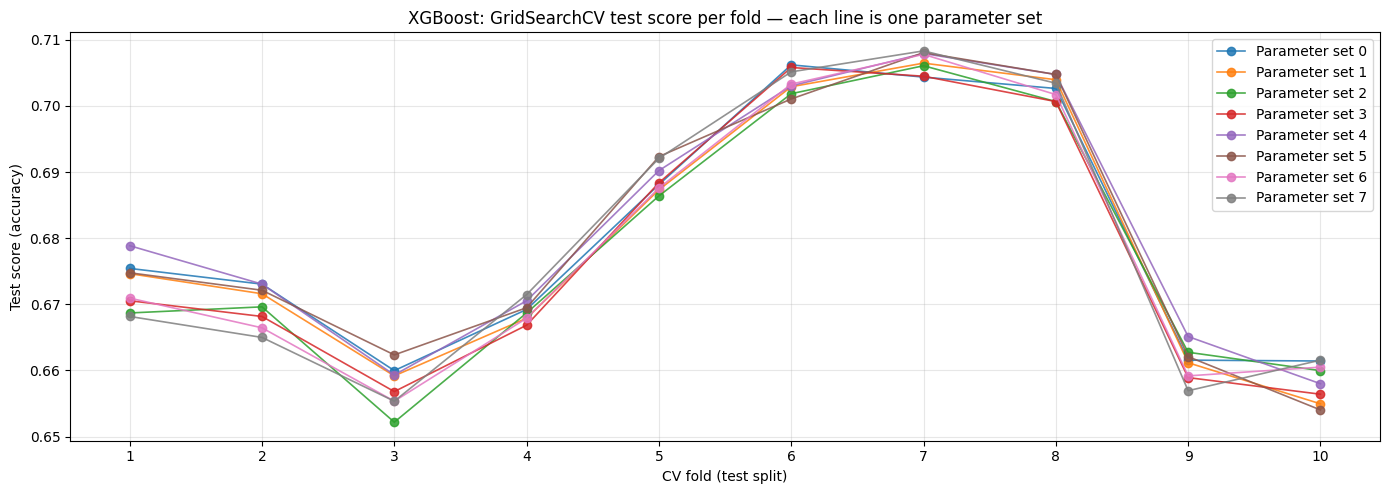


Grid search for XGBoost model

Best CV score (mean across folds): 0.6811
Best params: {'model__colsample_bytree': 1.0, 'model__eval_metric': 'logloss', 'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__n_estimators': 200, 'model__n_jobs': 1, 'model__random_state': 42, 'model__subsample': 0.8, 'model__tree_method': 'hist'}

Test results for XGBoost model
14,081 / 20,819 correct (67.64%); precision=0.6782, recall=0.6782, F1=0.6782, ROC-AUC=0.7441


In [145]:
XGB_MODEL_NAME = "XGBoost"

XGB_PARAM_GRID = {
    "model__n_estimators": [200],
    "model__max_depth": [4, 6],
    "model__learning_rate": [0.05],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__random_state": [RANDOM_STATE],
    "model__n_jobs": [1],
    "model__eval_metric": ["logloss"],
    "model__tree_method": ["hist"],
}

_transformers_xgb = []
if metadata_cols:
    _transformers_xgb.append(("drop_metadata", "drop", metadata_cols))
_transformers_xgb.append(("num", SimpleImputer(strategy="median"), numeric_features))
if categorical_features:
    _transformers_xgb.append(
        (
            "cat",
            Pipeline(
                steps=[
                    # ("impute", SimpleImputer(strategy="most_frequent")),
                    (
                        "onehot",
                        OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                    ),
                ]
            ),
            categorical_features,
        )
    )

preprocessor_xgb = ColumnTransformer(transformers=_transformers_xgb)

xgb_pipeline = Pipeline(
    steps=[
        ("prep", preprocessor_xgb),
        ("model", XGBClassifier()),
    ]
)

xgb_model = train_and_test_model(XGB_MODEL_NAME, xgb_pipeline, XGB_PARAM_GRID)

### CatBoost

**`verbose=False`** and **`allow_writing_files=False`** keep runs quiet in the notebook.

Fitting 10 folds for each of 4 candidates, totalling 40 fits

Parameter sets ranked by test score
#1 - Parameter set 1 with score 0.6809247027741083:
  {'model__allow_writing_files': False, 'model__depth': 4, 'model__iterations': 200, 'model__learning_rate': 0.1, 'model__loss_function': 'Logloss', 'model__random_state': 42, 'model__thread_count': 1, 'model__verbose': False}
#2 - Parameter set 2 with score 0.6803830911492735:
  {'model__allow_writing_files': False, 'model__depth': 8, 'model__iterations': 200, 'model__learning_rate': 0.05, 'model__loss_function': 'Logloss', 'model__random_state': 42, 'model__thread_count': 1, 'model__verbose': False}
#3 - Parameter set 0 with score 0.6802906208718627:
  {'model__allow_writing_files': False, 'model__depth': 4, 'model__iterations': 200, 'model__learning_rate': 0.05, 'model__loss_function': 'Logloss', 'model__random_state': 42, 'model__thread_count': 1, 'model__verbose': False}
#4 - Parameter set 3 with score 0.6754953764861295:
  {'model__

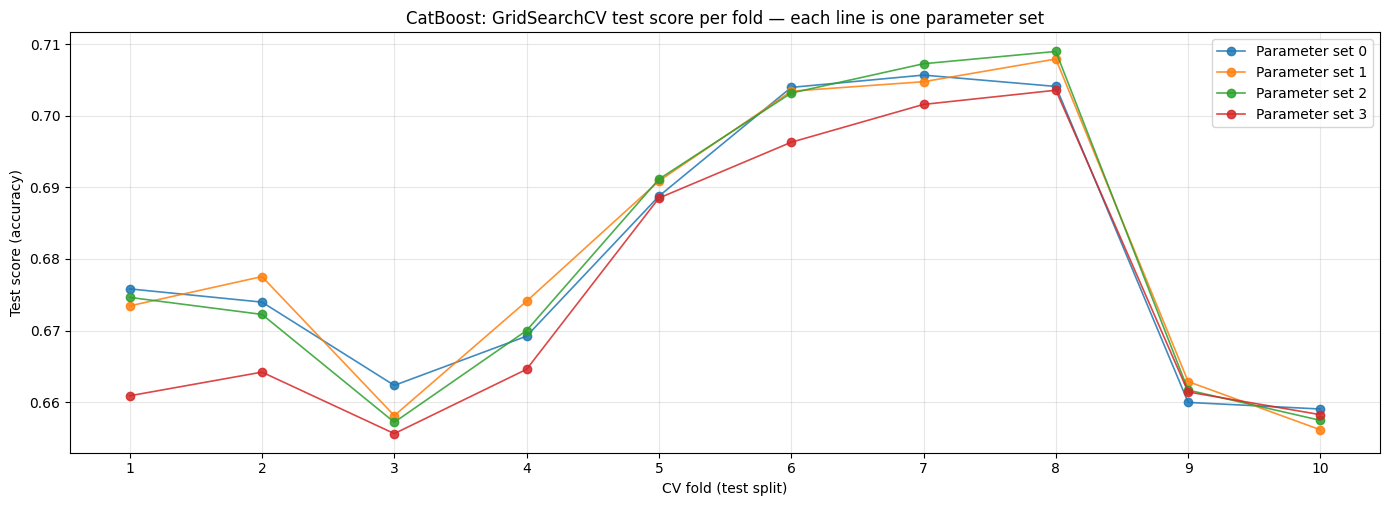


Grid search for CatBoost model

Best CV score (mean across folds): 0.6809
Best params: {'model__allow_writing_files': False, 'model__depth': 4, 'model__iterations': 200, 'model__learning_rate': 0.1, 'model__loss_function': 'Logloss', 'model__random_state': 42, 'model__thread_count': 1, 'model__verbose': False}

Test results for CatBoost model
14,128 / 20,819 correct (67.86%); precision=0.6791, recall=0.6840, F1=0.6815, ROC-AUC=0.7446


In [188]:
CAT_MODEL_NAME = "CatBoost"

CAT_PARAM_GRID = {
    "model__iterations": [200],
    "model__depth": [4, 8],
    "model__learning_rate": [0.05, 0.1],
    "model__random_state": [RANDOM_STATE],
    "model__verbose": [False],
    "model__loss_function": ["Logloss"],
    "model__allow_writing_files": [False],
    "model__thread_count": [1],
}

_transformers_cat = []
if metadata_cols:
    _transformers_cat.append(("drop_metadata", "drop", metadata_cols))
_transformers_cat.append(("num", SimpleImputer(strategy="median"), numeric_features))
if categorical_features:
    _transformers_cat.append(
        (
            "cat",
            Pipeline(
                steps=[
                    # ("impute", SimpleImputer(strategy="most_frequent")),
                    (
                        "onehot",
                        OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                    ),
                ]
            ),
            categorical_features,
        )
    )

preprocessor_cat = ColumnTransformer(transformers=_transformers_cat)

cat_pipeline = Pipeline(
    steps=[
        ("prep", preprocessor_cat),
        ("model", CatBoostClassifier()),
    ]
)

catboost_model = train_and_test_model(CAT_MODEL_NAME, cat_pipeline, CAT_PARAM_GRID)

# 6. Analysis

## SHapley Additive exPlanations

100%|===================| 20805/20819 [00:48<00:00]        

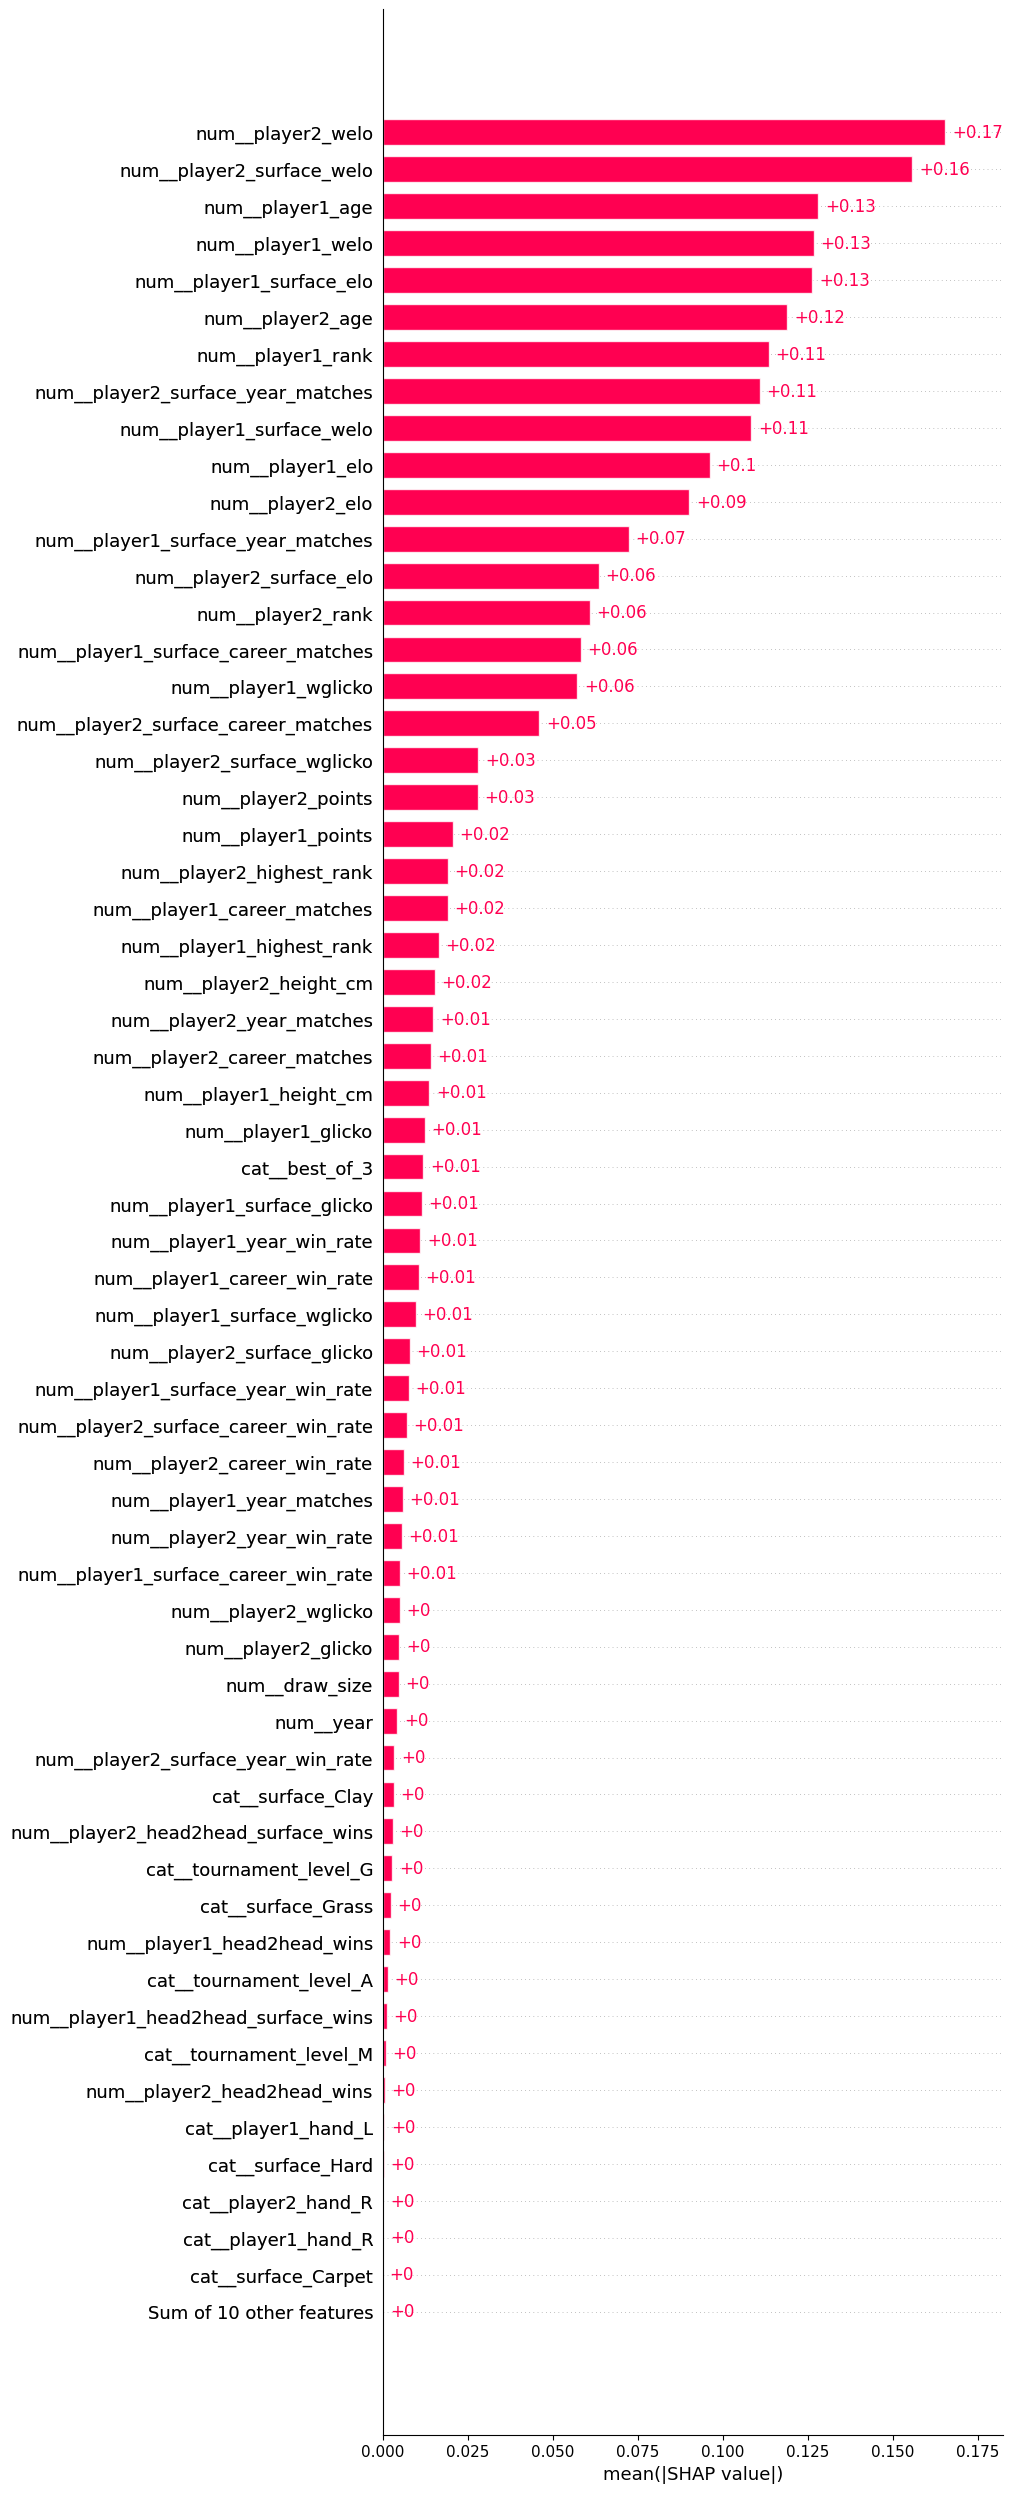

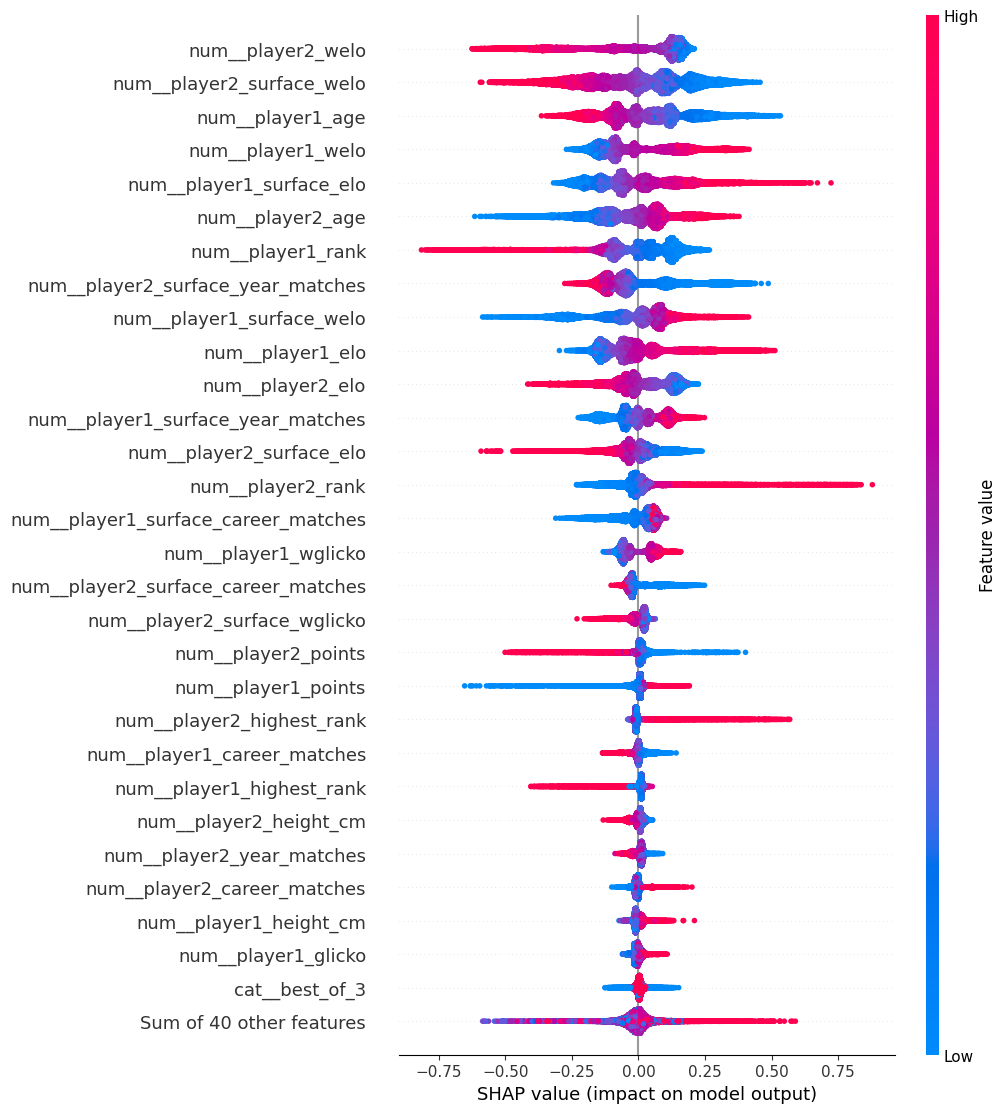

In [146]:
shap_analysis(xgb_model)